##Zomato Order Analysis 

Tasks: 

Objective Of the Study: To analyze Zomato order data to uncover trends in customer behavior, restaurant performance, and ordering patterns.

*Type of Data:Zomato Order Analysis 
*Model Used: Exploratory Data Analytics 


Define the problem  

Checking versions of libraries 
 
importing libraries into this notebook
 
Cleaning of data - Pre-Processing of data 

summarizing data set to extract actionable insights 

visualization of data 

conclusion 
    

In [186]:
pip install missingno

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [188]:
df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Desktop\\zomato project\\zomatonew.csv",low_memory = False) 
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [189]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55977,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
55978,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
55979,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
55980,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [190]:
df.columns


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [191]:
data = pd.read_csv("zomato.csv", low_memory = False, dtype={'rate': str})
print(df['rate'].unique())

['4.1/5' '3.8/5' '3.7/5' ...
 " this time I went with a friend and ordered a couple of my favourite things. I do wish we had bigger tummies because we did miss onto a couple of my favourites cz it was just 2 of us!\\n\\nI love :\\nCrunchy Mini tacos with BBQ chicken\\nCheese burst chicken\\nFries with good old Mac n cheese\\nSmoked chicken pita pockets\\nDrunk meatballs\\nTwo face chicken skewers\\nBelfast glazed chicken wings\\nHummus platter\\nHerbivores basket (so much variety)\\nGrande nachos\\nIrish Riverdance\\nDual chocolate torte\\n\\nA couple of mocktails like chili guava.\\n\\nI would say it is a bit pricy but totally worth the money because the food is very very yum!\\nI rest my case.')"
 ' Service:4/5\\n\\nOrder: Dynamite Shrimp Maki Rolls'
 ' but cud be a bit less spicy... otherwise was grt']


In [192]:
import re 
def clean_rate(val):
    if isinstance(val, str):
        match = re.match(r'^(\d\.\d)/5$', val.strip())
        if match:
            return float(match.group(1))
    return np.nan

data['rate'] = data['rate'].apply(clean_rate)

In [193]:
print(data['rate'].unique())
print(data['rate'].isnull().sum())

[4.1 3.8 3.7 3.6 4.6 4.  nan 4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 2.9 3.5
 2.6 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]
34694


In [194]:
data

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,Unnamed: 4150,Unnamed: 4151,Unnamed: 4152,Unnamed: 4153,Unnamed: 4154,Unnamed: 4155,Unnamed: 4156,Unnamed: 4157,Unnamed: 4158,Unnamed: 4159
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55977,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,NaN,27,080 40301477,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55978,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55979,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55980,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,NaN,236,080 49652769,"ITPL Main Road, Whitefield",Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [195]:
data['rate'] = pd.to_numeric(data['rate'], errors='coerce')

# Fill NaN values in 'rate' column with the mean of the column
data['rate'].fillna(data['rate'].mean(), inplace=True)

# Optional: check if there are any NaNs left
print("Remaining NaNs in rate column:", data['rate'].isnull().sum())

Remaining NaNs in rate column: 0


In [196]:
data

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,Unnamed: 4150,Unnamed: 4151,Unnamed: 4152,Unnamed: 4153,Unnamed: 4154,Unnamed: 4155,Unnamed: 4156,Unnamed: 4157,Unnamed: 4158,Unnamed: 4159
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.100000,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.100000,787,080 41714161,Banashankari,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.800000,918,+91 9663487993,Banashankari,"Cafe, Casual Dining",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.700000,88,+91 9620009302,Banashankari,Quick Bites,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.800000,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55977,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.681548,27,080 40301477,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55978,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,3.681548,0,+91 8197675843,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55979,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.681548,0,NaN,Whitefield,Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55980,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,3.681548,236,080 49652769,"ITPL Main Road, Whitefield",Bar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [197]:

df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [198]:
data1=df.drop(['url','menu_item','phone','address','dish_liked','menu_item','reviews_list','listed_in(city)'],axis=1)
data1

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...
55977,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,Continental,"1,500",Pubs and bars
55978,Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,Pubs and bars
55979,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,Finger Food,"2,000",Pubs and bars
55980,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500",Pubs and bars


In [200]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [201]:
data1.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)'],
      dtype='object')

In [202]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55982 entries, 0 to 55981
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         55976 non-null  object
 1   online_order                 55977 non-null  object
 2   book_table                   55949 non-null  object
 3   rate                         48164 non-null  object
 4   votes                        55927 non-null  object
 5   location                     55893 non-null  object
 6   rest_type                    55676 non-null  object
 7   cuisines                     55836 non-null  object
 8   approx_cost(for two people)  55519 non-null  object
 9   listed_in(type)              51576 non-null  object
dtypes: object(10)
memory usage: 4.3+ MB


In [203]:
data1.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


In [204]:
data1.shape

(55982, 10)

In [205]:
data1.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
55977    False
55978    False
55979    False
55980    False
55981    False
Length: 55982, dtype: bool

In [206]:
data1[data1.duplicated()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
577,Wamama,Yes,Yes,4.2/5,354,Banashankari,Casual Dining,"Asian, Korean, Indonesian, Japanese, Chinese, ...",800,NaN
589,Peppy Peppers,No,No,4.2/5,244,Banashankari,Casual Dining,"Italian, North Indian, Mexican",800,NaN
608,Dal Tadkaa,Yes,No,2.5/5,247,Banashankari,Casual Dining,North Indian,500,NaN
609,"""""RATED\n The buffet is inr 330 pp all incl....",so is the variety. Daal baati didn't feel lik...,but at that price range,you can definitely hang in domino's and get a...,('Rated 2.5',they had a board that said spl buffet. There ...,only served buffet style,the server says it is on the other table mada...,('Rated 3.5',my expression was it has to be Veg restaurant...
617,Kadala Tarangaa,Yes,No,3.6/5,129,Banashankari,Casual Dining,"Mangalorean, Seafood, North Indian",600,NaN
...,...,...,...,...,...,...,...,...,...,...
55956,The Irish House,No,Yes,4.3 /5,1776,Whitefield,"Casual Dining, Pub","European, American","1,700",NaN
55958,Shizusan Shophouse & Bar,Yes,Yes,4.4 /5,1313,Whitefield,"Casual Dining, Bar","Asian, Japanese, Vietnamese, Korean, Chinese, ...","1,800",NaN
55963,BAR BAR,No,Yes,4.1 /5,1003,Whitefield,"Bar, Casual Dining","Continental, North Indian, Italian","1,500",NaN
55965,The Beer Cafe,Yes,Yes,4.1 /5,673,Whitefield,Pub,"Finger Food, North Indian, Chinese, Italian","1,400",NaN


In [207]:
data1.drop_duplicates(keep = 'first' , inplace = True )

In [208]:
data1.shape

(38268, 10)

In [209]:
data1.isnull().sum()

name                              3
online_order                      2
book_table                       25
rate                           3805
votes                            47
location                         74
rest_type                       225
cuisines                        122
approx_cost(for two people)     324
listed_in(type)                2667
dtype: int64

In [210]:
null_values = {i:data1[i].isnull().sum() for i in data1.columns} #it is same has privious code in deffirent way

null_values

{'name': 3,
 'online_order': 2,
 'book_table': 25,
 'rate': 3805,
 'votes': 47,
 'location': 74,
 'rest_type': 225,
 'cuisines': 122,
 'approx_cost(for two people)': 324,
 'listed_in(type)': 2667}

In [211]:
empty_data = data1.isnull().sum() #just i want to show only null value 
empty_data[empty_data>0]

name                              3
online_order                      2
book_table                       25
rate                           3805
votes                            47
location                         74
rest_type                       225
cuisines                        122
approx_cost(for two people)     324
listed_in(type)                2667
dtype: int64

In [212]:
data1[data1.isnull().any(axis=1)]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
8,Penthouse Cafe,Yes,No,4.0/5,324,Banashankari,Cafe,"Cafe, Italian, Continental",700,NaN
32,Foodiction,Yes,No,2.8/5,506,Banashankari,Quick Bites,"North Indian, Fast Food, Chinese, Burger",500,NaN
36,Faasos,Yes,No,4.2/5,415,Banashankari,Quick Bites,"North Indian, Biryani, Fast Food",500,NaN
41,Empire Restaurant,Yes,No,4.4/5,4884,Jayanagar,Casual Dining,"North Indian, Mughlai, South Indian, Chinese",750,NaN
48,Onesta,Yes,Yes,4.6/5,2556,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600,NaN
...,...,...,...,...,...,...,...,...,...,...
55961,Harry's Bar + Cafe,Yes,Yes,4.1 /5,1218,Whitefield,Pub,"Asian, American, Mexican","1,200",NaN
55962,Pubs and bars,Whitefield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55975,Topsy Turvey,No,No,NaN,0,Whitefield,Bar,Finger Food,900,Pubs and bars
55978,Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,Finger Food,600,Pubs and bars


In [213]:
# pip install missingno

Text(0, 0.5, 'Count')

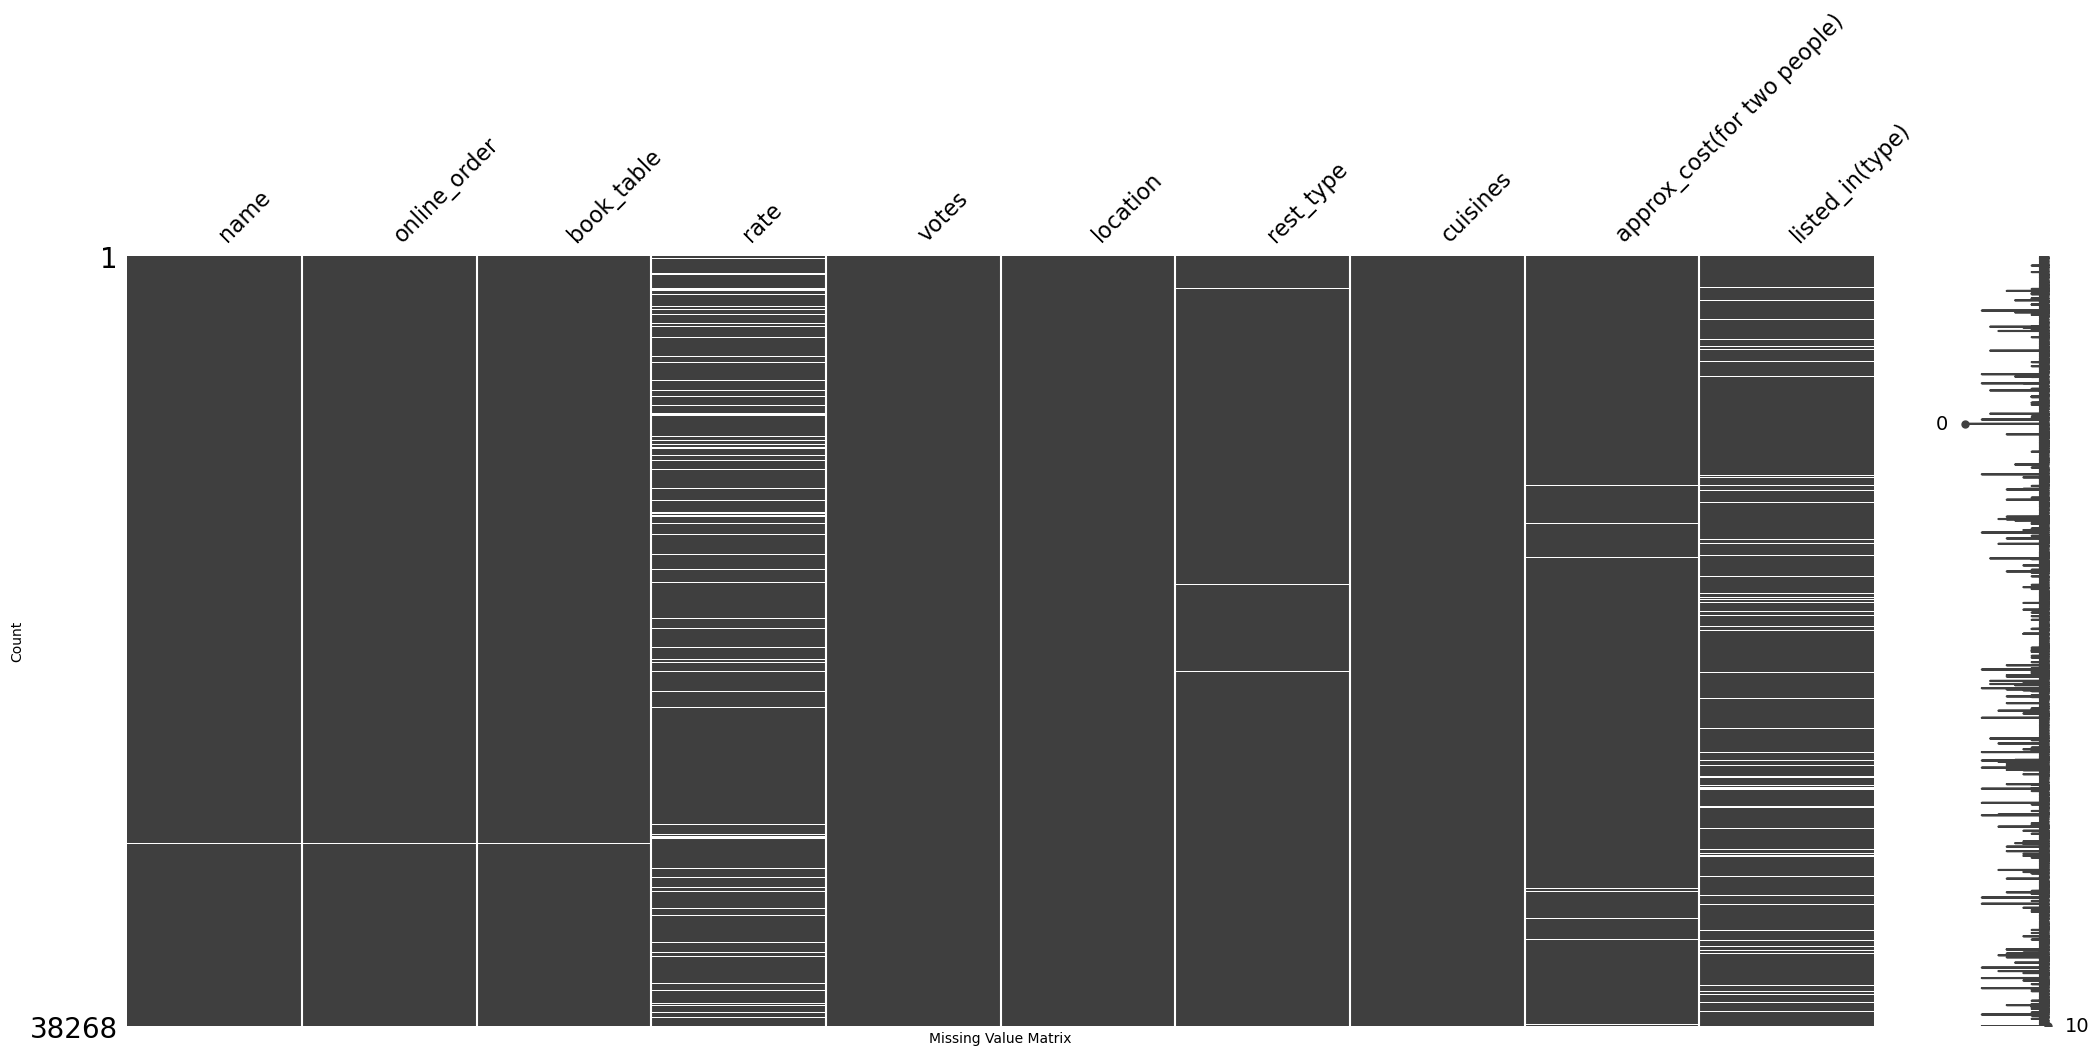

In [214]:
import missingno as msno
msno.matrix(data1)
plt.xlabel("Missing Value Matrix")
plt.ylabel("Count")

In [215]:
print("There are {} values are unique in Rate Columns".format(len(data1["rate"].unique())))
                                #it gives the length of the unique value in the rate column

data1["rate"].unique()

There are 2878 values are unique in Rate Columns


array(['4.1/5', '3.8/5', '3.7/5', ...,
       " this time I went with a friend and ordered a couple of my favourite things. I do wish we had bigger tummies because we did miss onto a couple of my favourites cz it was just 2 of us!\\n\\nI love :\\nCrunchy Mini tacos with BBQ chicken\\nCheese burst chicken\\nFries with good old Mac n cheese\\nSmoked chicken pita pockets\\nDrunk meatballs\\nTwo face chicken skewers\\nBelfast glazed chicken wings\\nHummus platter\\nHerbivores basket (so much variety)\\nGrande nachos\\nIrish Riverdance\\nDual chocolate torte\\n\\nA couple of mocktails like chili guava.\\n\\nI would say it is a bit pricy but totally worth the money because the food is very very yum!\\nI rest my case.')",
       ' Service:4/5\\n\\nOrder: Dynamite Shrimp Maki Rolls',
       ' but cud be a bit less spicy... otherwise was grt'], dtype=object)

In [216]:
def rate(data1):                          #using function and function name is data
    if data1 == "NEW" or data1 == "-":     #if any columns have "NEW","-" it convert to nun
        return np.nan                    #NumPy NAN stands for not a number and is defined as a substitute for declaring value
                                                   #which are numerical values that are missing values in an array 
    else:                                   
        data1 = str(data1).split("/")       # i split the data "/"
        data1 = data1[0]                     #data[0] is index number
        return float(data1)

In [217]:
data1['rate'] = data1['rate'].astype(str)

# Step 2: Filter out long junk values
data1 = data1[data1['rate'].str.len() < 10].reset_index(drop=True)

# Step 3: Keep only valid patterns
data1 = data1[data1['rate'].str.match(r'^\d+(\.\d+)?/5$|^NEW$|^-$')].reset_index(drop=True)

# Step 4: Replace 'NEW' and '-' with NaN
import numpy as np
data1['rate'] = data1['rate'].replace(['NEW', '-'], np.nan)

# Step 5: Strip '/5' and convert to float
data1['rate'] = data1['rate'].str.replace('/5', '', regex=False)
data1['rate'] = data1['rate'].astype(float)

# Check results
print("Cleaned rate values:", data1['rate'].unique())

Cleaned rate values: [4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 nan 2.9 3.5
 2.6 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]


In [218]:
data1.isnull().sum()

name                              0
online_order                      0
book_table                        0
rate                           1327
votes                             0
location                          0
rest_type                        63
cuisines                          3
approx_cost(for two people)      58
listed_in(type)                1065
dtype: int64

In [219]:
data1.dropna(inplace = True)

In [220]:
data1.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [221]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13843 entries, 0 to 16036
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         13843 non-null  object 
 1   online_order                 13843 non-null  object 
 2   book_table                   13843 non-null  object 
 3   rate                         13843 non-null  float64
 4   votes                        13843 non-null  object 
 5   location                     13843 non-null  object 
 6   rest_type                    13843 non-null  object 
 7   cuisines                     13843 non-null  object 
 8   approx_cost(for two people)  13843 non-null  object 
 9   listed_in(type)              13843 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [222]:
data1.rename(columns = {"approx_cost(for two people)":"Cost2plate","listed_in(type)":"Type"},inplace = True)

In [223]:
data1

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plate,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...
16031,Fudgy Love Designer Cakes,No,No,3.7,20,Domlur,"Bakery, Dessert Parlor","Bakery, Desserts",600,Desserts
16032,Cafe Velvette,No,No,3.5,11,Domlur,"Cafe, Dessert Parlor","Cafe, American, Italian, Continental",400,Desserts
16033,New Surya Sweets & Snacks,No,No,3.2,5,BTM,Sweet Shop,"Mithai, Street Food",350,Desserts
16034,Kulfisthan,Yes,No,3.5,7,HSR,Dessert Parlor,Ice Cream,150,Desserts


In [224]:
data1["Cost2plate"].unique()

array(['800', '300', '600', '550', '500', '450', '650', '700', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '1,100', '1,600', '230',
       '130', '1,700', '1,350', '2,200', '2,000', '1,400', '1,800',
       '1,900', '180', '330', '2,500', '3,000', '2,800', '50', '40',
       '2,100', '1,250', '3,500', '3,400', '4,000', '2,400', '2,600',
       '1,450', '70', '3,200', '240', '6,000', '1,050'], dtype=object)

In [225]:
data1["rest_type"].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Dessert Parlor, Sweet Shop', 'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites', 'Kiosk', 'Food Truck',
       'Quick Bites, Dessert Parlor', 'Beverage Shop, Quick Bites',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Dhaba', 'Quick Bites, Sweet Shop',
       'Microbrewery', 'Food Court, Quick Bites',
       'Quick Bites, Beverage Shop', 'Pub, Bar', 'Casual Dining, Pub',
       'Lounge, Bar', 'Dessert Parlor, Quick Bites',
       'Food Court, Dessert Parlor', 'Casual Dining

In [226]:
def remove_comma(data1):           #i am using function the function name is remove_comma
    data1 = data1.replace(",","")   ## in Cost2plate columns most of value containg comma and comma represent object datatype
                                                              # but my data should be in floattype.
    return float(data1) 

In [227]:
data1["Cost2plate"].apply(remove_comma)

0        800.0
1        800.0
2        800.0
3        300.0
4        600.0
         ...  
16031    600.0
16032    400.0
16033    350.0
16034    150.0
16036    150.0
Name: Cost2plate, Length: 13843, dtype: float64

In [228]:
data1["Cost2plate"] = data1["Cost2plate"].apply(remove_comma)

In [229]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13843 entries, 0 to 16036
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          13843 non-null  object 
 1   online_order  13843 non-null  object 
 2   book_table    13843 non-null  object 
 3   rate          13843 non-null  float64
 4   votes         13843 non-null  object 
 5   location      13843 non-null  object 
 6   rest_type     13843 non-null  object 
 7   cuisines      13843 non-null  object 
 8   Cost2plate    13843 non-null  float64
 9   Type          13843 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [230]:
data1['rest_type'].value_counts().rename('rest_type')

rest_type
Quick Bites                      4756
Casual Dining                    3363
Cafe                             1091
Dessert Parlor                    691
Delivery                          563
Takeaway, Delivery                458
Casual Dining, Bar                308
Bakery                            283
Beverage Shop                     212
Bar                               177
Food Court                        144
Lounge                            120
Sweet Shop                        115
Fine Dining                       107
Bakery, Quick Bites                90
Beverage Shop, Quick Bites         88
Pub                                79
Casual Dining, Cafe                77
Bar, Casual Dining                 64
Pub, Casual Dining                 64
Sweet Shop, Quick Bites            61
Kiosk                              58
Mess                               58
Cafe, Dessert Parlor               52
Cafe, Casual Dining                52
Cafe, Bakery                       49
Ca

In [231]:
rest_type=data1['rest_type'].value_counts()  #i assigned data to rest_type variable
rest_type

rest_type
Quick Bites                      4756
Casual Dining                    3363
Cafe                             1091
Dessert Parlor                    691
Delivery                          563
Takeaway, Delivery                458
Casual Dining, Bar                308
Bakery                            283
Beverage Shop                     212
Bar                               177
Food Court                        144
Lounge                            120
Sweet Shop                        115
Fine Dining                       107
Bakery, Quick Bites                90
Beverage Shop, Quick Bites         88
Pub                                79
Casual Dining, Cafe                77
Bar, Casual Dining                 64
Pub, Casual Dining                 64
Sweet Shop, Quick Bites            61
Kiosk                              58
Mess                               58
Cafe, Dessert Parlor               52
Cafe, Casual Dining                52
Cafe, Bakery                       49
Ca

In [232]:
rest_type_lessthan1000=rest_type[rest_type<1000]  # filtered the data lessthan 1000 and assign
rest_type_lessthan1000.rename('rest_type')

rest_type
Dessert Parlor                   691
Delivery                         563
Takeaway, Delivery               458
Casual Dining, Bar               308
Bakery                           283
Beverage Shop                    212
Bar                              177
Food Court                       144
Lounge                           120
Sweet Shop                       115
Fine Dining                      107
Bakery, Quick Bites               90
Beverage Shop, Quick Bites        88
Pub                               79
Casual Dining, Cafe               77
Bar, Casual Dining                64
Pub, Casual Dining                64
Sweet Shop, Quick Bites           61
Kiosk                             58
Mess                              58
Cafe, Dessert Parlor              52
Cafe, Casual Dining               52
Cafe, Bakery                      49
Casual Dining, Pub                46
Dessert Parlor, Cafe              43
Bakery, Dessert Parlor            43
Cafe, Quick Bites           

In [233]:
def handle_rest_type(value):                   # using function like whereever 1 to 1000 data is their then i shows 'Others'
    if(value in rest_type_lessthan1000):                                        # by using if statement
        return 'others'
    else:
        return value

In [234]:
data1['rest_type']=data1['rest_type'].apply(handle_rest_type)

In [235]:
data1['rest_type'].value_counts()

rest_type
Quick Bites      4756
others           4633
Casual Dining    3363
Cafe             1091
Name: count, dtype: int64

In [236]:
data1.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plate,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


In [237]:
data1['location'].value_counts().rename("location")

location
BTM                              1140
HSR                              1033
JP Nagar                          883
Indiranagar                       781
Electronic City                   777
Bannerghatta Road                 709
Jayanagar                         686
Koramangala 5th Block             471
Bellandur                         467
Marathahalli                      445
Banashankari                      423
Whitefield                        407
Kalyan Nagar                      327
Sarjapur Road                     292
Basavanagudi                      277
Brigade Road                      262
Frazer Town                       256
Ulsoor                            244
Brookefield                       232
Kammanahalli                      231
Koramangala 7th Block             226
Banaswadi                         220
MG Road                           207
Koramangala 1st Block             174
Koramangala 6th Block             162
Richmond Road                     148
Old

In [238]:

data1['location'].value_counts().rename("location")

location
BTM                              1140
HSR                              1033
JP Nagar                          883
Indiranagar                       781
Electronic City                   777
Bannerghatta Road                 709
Jayanagar                         686
Koramangala 5th Block             471
Bellandur                         467
Marathahalli                      445
Banashankari                      423
Whitefield                        407
Kalyan Nagar                      327
Sarjapur Road                     292
Basavanagudi                      277
Brigade Road                      262
Frazer Town                       256
Ulsoor                            244
Brookefield                       232
Kammanahalli                      231
Koramangala 7th Block             226
Banaswadi                         220
MG Road                           207
Koramangala 1st Block             174
Koramangala 6th Block             162
Richmond Road                     148
Old

In [239]:
data1['cuisines'].value_counts().rename("cuisines")

cuisines
North Indian                                        727
North Indian, Chinese                               702
South Indian                                        393
Bakery, Desserts                                    263
South Indian, North Indian, Chinese                 203
                                                   ... 
Singaporean, Chinese, Thai, Malaysian                 1
Continental, North Indian, Japanese, Italian          1
South Indian, North Indian, Continental, Chinese      1
North Indian, Chinese, Andhra, Seafood                1
Chinese, Mangalorean, North Indian                    1
Name: cuisines, Length: 1897, dtype: int64

In [240]:
data1['cuisines']=data1['cuisines'] #assigned
data1['cuisines'].value_counts().rename("cuisines")

cuisines
North Indian                                        727
North Indian, Chinese                               702
South Indian                                        393
Bakery, Desserts                                    263
South Indian, North Indian, Chinese                 203
                                                   ... 
Singaporean, Chinese, Thai, Malaysian                 1
Continental, North Indian, Japanese, Italian          1
South Indian, North Indian, Continental, Chinese      1
North Indian, Chinese, Andhra, Seafood                1
Chinese, Mangalorean, North Indian                    1
Name: cuisines, Length: 1897, dtype: int64

In [241]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13843 entries, 0 to 16036
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          13843 non-null  object 
 1   online_order  13843 non-null  object 
 2   book_table    13843 non-null  object 
 3   rate          13843 non-null  float64
 4   votes         13843 non-null  object 
 5   location      13843 non-null  object 
 6   rest_type     13843 non-null  object 
 7   cuisines      13843 non-null  object 
 8   Cost2plate    13843 non-null  float64
 9   Type          13843 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [242]:
data1['Type'].value_counts().rename("Type")

Type
Delivery              7092
Dine-out              4501
Desserts               990
Cafes                  533
Buffet                 280
Drinks & nightlife     250
Pubs and bars          197
Name: Type, dtype: int64

In [243]:
data1.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'Cost2plate', 'Type'],
      dtype='object')

In [244]:

data1.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plate,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


In [245]:
data1["location"].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Jayanagar', 'Uttarahalli', 'JP Nagar', 'South Bangalore',
       'City Market', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'Electronic City', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Richmond Road', 'HSR',
       'Koramangala 7th Block', 'Bellandur', 'Sarjapur Road',
       'Marathahalli', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'MG Road',
       'Brigade Road', 'Ulsoor', 'Lavelle Road', 'Residency Road',
       'Shivajinagar', 'Infantry Road', 'Cunningham Road',
       'Race Course Road', 'Church Street', 'St. Marks Road',
       'Commercial Street', 'Vasanth Nagar', 'Domlur',
       'Koramangala 8th Block', 'Ejipura', 'Jeevan Bhima Nagar',
       'Old Madras Road', 'Seshadripuram', 'Kammanahalli',
       'Koramangala 6th Block', 'Ma

In [246]:
data1["location"].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Jayanagar', 'Uttarahalli', 'JP Nagar', 'South Bangalore',
       'City Market', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'Electronic City', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Richmond Road', 'HSR',
       'Koramangala 7th Block', 'Bellandur', 'Sarjapur Road',
       'Marathahalli', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'MG Road',
       'Brigade Road', 'Ulsoor', 'Lavelle Road', 'Residency Road',
       'Shivajinagar', 'Infantry Road', 'Cunningham Road',
       'Race Course Road', 'Church Street', 'St. Marks Road',
       'Commercial Street', 'Vasanth Nagar', 'Domlur',
       'Koramangala 8th Block', 'Ejipura', 'Jeevan Bhima Nagar',
       'Old Madras Road', 'Seshadripuram', 'Kammanahalli',
       'Koramangala 6th Block', 'Ma

In [247]:
data1.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plate,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


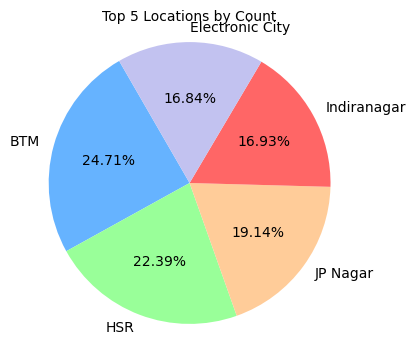

In [248]:
a = data1["location"].value_counts().head(5)

# Extract labels and values
labels = a.index
sizes = a.values

# Optional: custom colors
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff6666', '#c2c2f0']

# Plotting the pie chart
plt.figure(figsize=(4,4))
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct="%.2f%%",
        startangle=120)

plt.title("Top 5 Locations by Count", fontsize=10)
plt.axis('equal')  # Draw as a circle
plt.show()


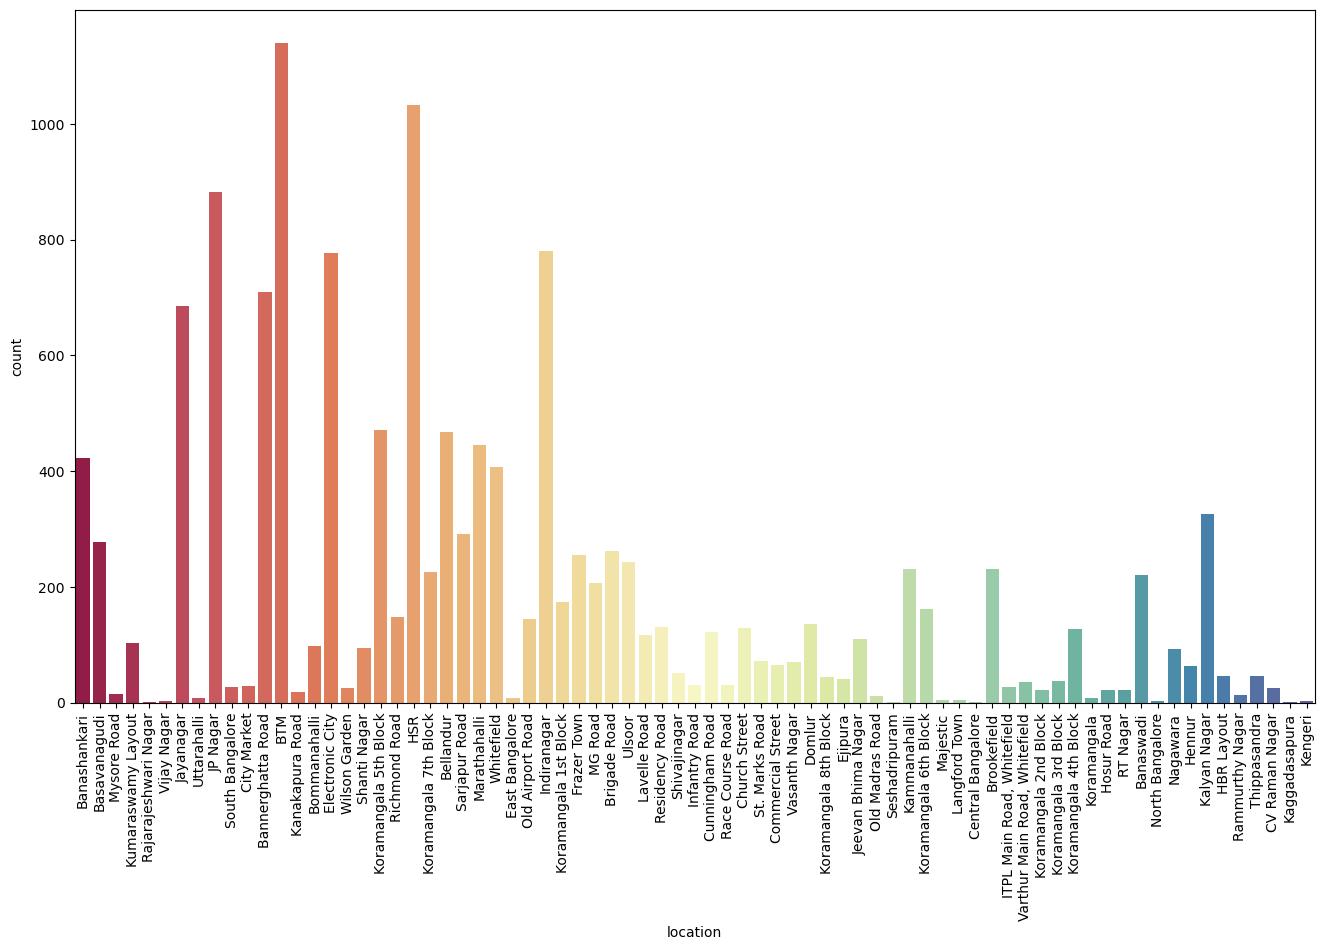

In [249]:
 
plt.figure(figsize = (16,9))  
ax = sns.countplot(data=data1,x='location',palette = 'Spectral')
plt.xticks(rotation=90)
plt.show()

In [250]:
data1.dtypes

name             object
online_order     object
book_table       object
rate            float64
votes            object
location         object
rest_type        object
cuisines         object
Cost2plate      float64
Type             object
dtype: object

In [251]:
data1['votes'] = data1['votes'].astype(str).str.replace(',', '')  # Remove commas
data1['votes'] = pd.to_numeric(data1['votes'], errors='coerce')

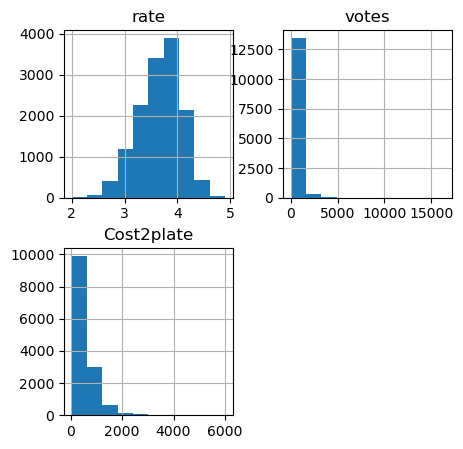

In [252]:
data1.hist(bins=10, figsize=(5,5))
plt.show()

<Axes: xlabel='online_order', ylabel='count'>

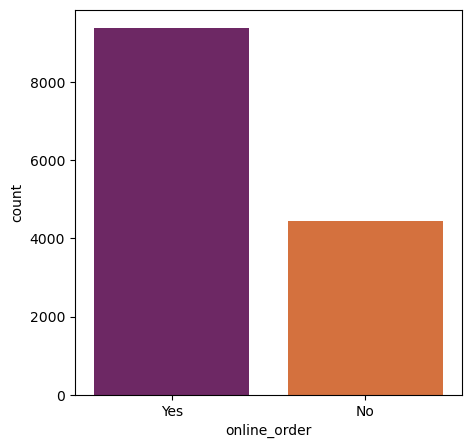

In [253]:
plt.figure(figsize = (5,5))
sns.countplot(data=data1,x='online_order', palette = 'inferno')

<Axes: xlabel='book_table', ylabel='count'>

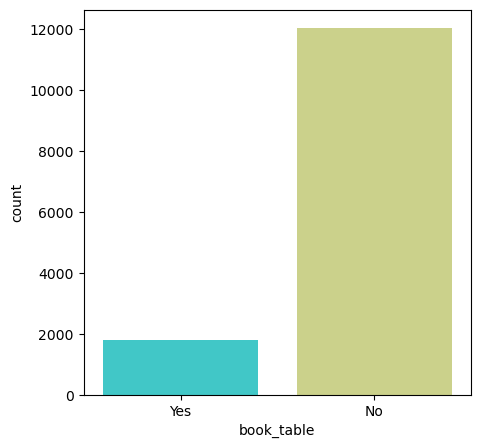

In [254]:
plt.figure(figsize = (5,5))
sns.countplot(data=data1,x='book_table', palette = 'rainbow')

<Axes: xlabel='online_order', ylabel='rate'>

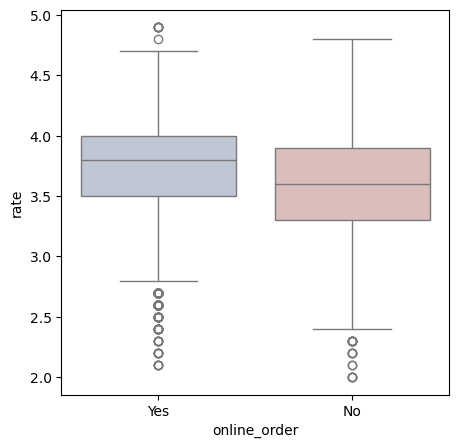

In [255]:
plt.figure(figsize = (5,5))
sns.boxplot(x = 'online_order', y = 'rate',data = data1 ,orient='v', palette = 'vlag')

<Axes: xlabel='book_table', ylabel='rate'>

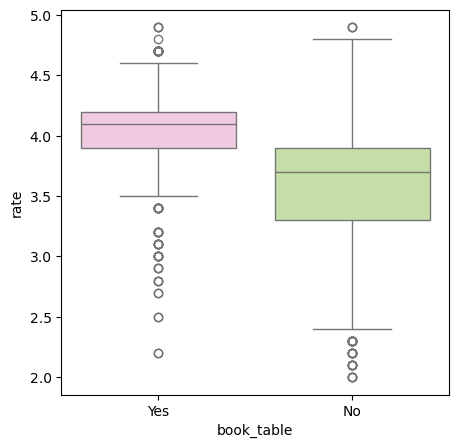

In [256]:
plt.figure(figsize = (5,5))
sns.boxplot(x = 'book_table', y = 'rate', data = data1 , palette = 'PiYG')

In [257]:
df2 = data1.groupby(['location','online_order'])['name'].count() # i am going to grouping my data location wise and i 
                                                                              #going to create new csv formate.
    
#to_csv() function converts DataFrame into CSV data. We can pass a file object to write the CSV data into a file.
                                     #Otherwise, the CSV data is returned in the string format.       
df2.to_csv('location_online.csv')
df2 = pd.read_csv('location_online.csv')
df2 = pd.pivot_table(df2, values=None, index=['location'], columns=['online_order'], fill_value=0, aggfunc=np.sum)
df2

name     
online_order                    No  Yes
location                               
BTM                            278  862
Banashankari                   156  267
Banaswadi                       82  138
Bannerghatta Road              206  503
Basavanagudi                    79  198
Bellandur                      151  316
Bommanahalli                    42   56
Brigade Road                    91  171
Brookefield                     66  166
CV Raman Nagar                   6   19
Central Bangalore                1    0
Church Street                   50   79
City Market                     20    9
Commercial Street               31   34
Cunningham Road                 43   80
Domlur                          61   76
East Bangalore                   4    5
Ejipura                         11   30
Electronic City                343  434
Frazer Town                    113  143
HBR Layout                       8   39
HSR                            217  816
Hennur                          10   54
Hosur Road                       5   17
ITPL Main Road, Whitefield       4   24
Indiranagar                    273  508
Infantry Road                   19   12
JP Nagar                       266  617
Jayanagar                      201  485
Jeevan Bhima Nagar              25   86
Kaggadasapura                    0    1
Kalyan Nagar                   109  218
Kammanahalli                    77  154
Kanakapura Road                  2   16
Kengeri                          0    4
Koramangala                      2    6
Koramangala 1st Block           32  142
Koramangala 2nd Block            7   15
Koramangala 3rd Block           14   24
Koramangala 4th Block           48   79
Koramangala 5th Block          135  336
Koramangala 6th Block           46  116
Koramangala 7th Block           57  169
Koramangala 8th Block           10   34
Kumaraswamy Layout              11   93
Langford Town                    4    1
Lavelle Road                    71   46
MG Road                        116   91
Majestic                         3    2
Marathahalli                    94  351
Mysore Road                      7    8
Nagawara                         7   86
North Bangalore                  3    1
Old Airport Road                68   76
Old Madras Road                  3    9
RT Nagar                         5   18
Race Course Road                22    8
Rajarajeshwari Nagar             0    2
Rammurthy Nagar                  1   13
Residency Road                  81   50
Richmond Road                   83   65
Sarjapur Road                   49  243
Seshadripuram                    0    2
Shanti Nagar                    46   49
Shivajinagar                    32   20
South Bangalore                 10   18
St. Marks Road                  36   37
Thippasandra                    21   26
Ulsoor                          82  162
Uttarahalli                      0    9
Varthur Main Road, Whitefield    3   33
Vasanth Nagar                   31   39
Vijay Nagar                      0    4
Whitefield                     149  258
Wilson Garden                   11   15

In [258]:
pd.set_option('display.max_rows', 100)

In [259]:
df2

name     
online_order                    No  Yes
location                               
BTM                            278  862
Banashankari                   156  267
Banaswadi                       82  138
Bannerghatta Road              206  503
Basavanagudi                    79  198
Bellandur                      151  316
Bommanahalli                    42   56
Brigade Road                    91  171
Brookefield                     66  166
CV Raman Nagar                   6   19
Central Bangalore                1    0
Church Street                   50   79
City Market                     20    9
Commercial Street               31   34
Cunningham Road                 43   80
Domlur                          61   76
East Bangalore                   4    5
Ejipura                         11   30
Electronic City                343  434
Frazer Town                    113  143
HBR Layout                       8   39
HSR                            217  816
Hennur                          10   54
Hosur Road                       5   17
ITPL Main Road, Whitefield       4   24
Indiranagar                    273  508
Infantry Road                   19   12
JP Nagar                       266  617
Jayanagar                      201  485
Jeevan Bhima Nagar              25   86
Kaggadasapura                    0    1
Kalyan Nagar                   109  218
Kammanahalli                    77  154
Kanakapura Road                  2   16
Kengeri                          0    4
Koramangala                      2    6
Koramangala 1st Block           32  142
Koramangala 2nd Block            7   15
Koramangala 3rd Block           14   24
Koramangala 4th Block           48   79
Koramangala 5th Block          135  336
Koramangala 6th Block           46  116
Koramangala 7th Block           57  169
Koramangala 8th Block           10   34
Kumaraswamy Layout              11   93
Langford Town                    4    1
Lavelle Road                    71   46
MG Road                        116   91
Majestic                         3    2
Marathahalli                    94  351
Mysore Road                      7    8
Nagawara                         7   86
North Bangalore                  3    1
Old Airport Road                68   76
Old Madras Road                  3    9
RT Nagar                         5   18
Race Course Road                22    8
Rajarajeshwari Nagar             0    2
Rammurthy Nagar                  1   13
Residency Road                  81   50
Richmond Road                   83   65
Sarjapur Road                   49  243
Seshadripuram                    0    2
Shanti Nagar                    46   49
Shivajinagar                    32   20
South Bangalore                 10   18
St. Marks Road                  36   37
Thippasandra                    21   26
Ulsoor                          82  162
Uttarahalli                      0    9
Varthur Main Road, Whitefield    3   33
Vasanth Nagar                   31   39
Vijay Nagar                      0    4
Whitefield                     149  258
Wilson Garden                   11   15

<Axes: xlabel='location'>

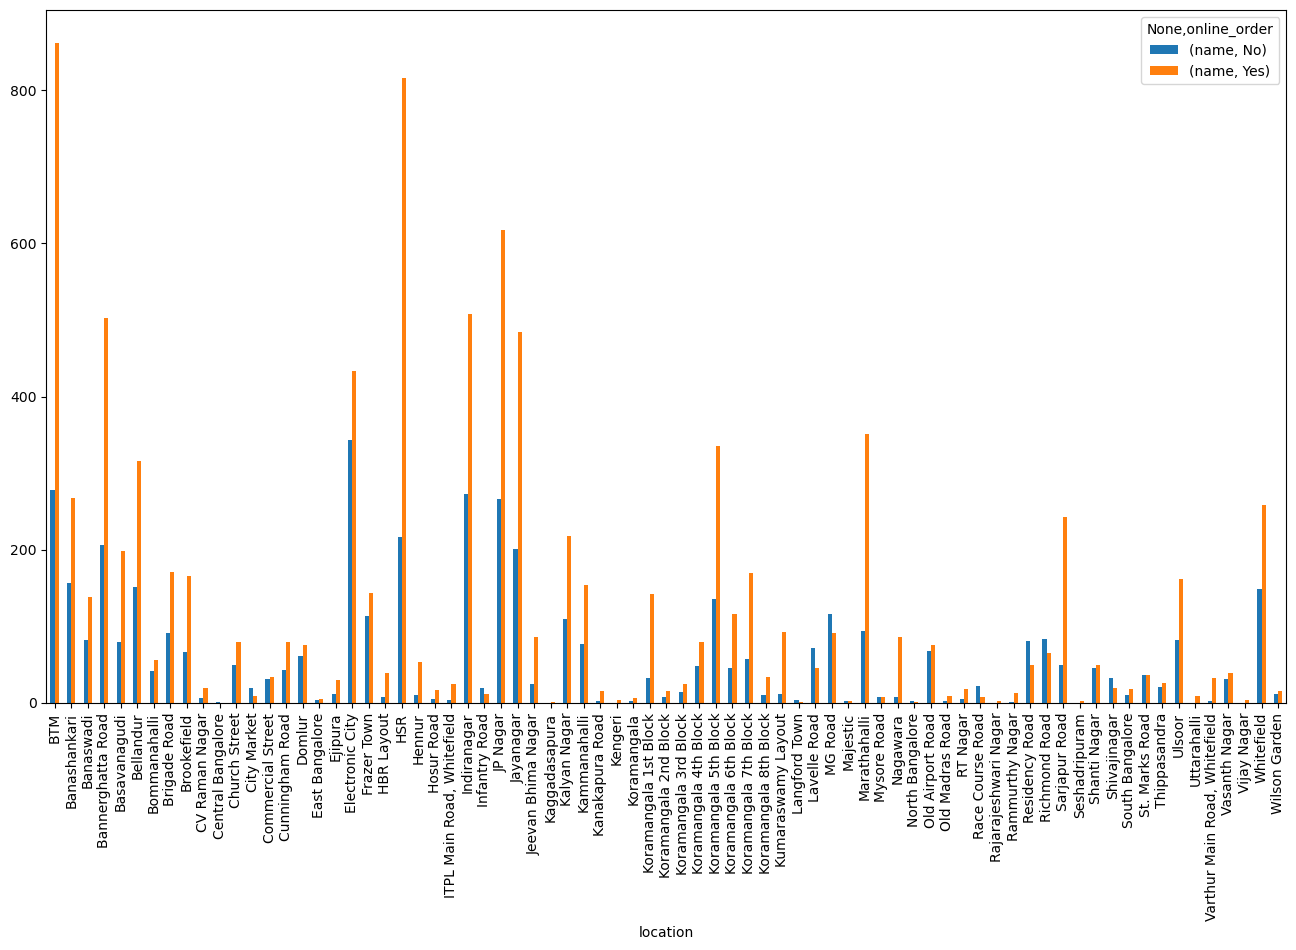

In [260]:
df2.plot(kind = 'bar', figsize = (16,9))

In [261]:
df3 = data1.groupby(['location','book_table'])['name'].count()
df3.to_csv('location_booktable.csv')
df3 = pd.read_csv('location_booktable.csv')
df3 = pd.pivot_table(df3, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)
df3

name     
book_table                       No  Yes
location                                
BTM                            1084   56
Banashankari                    393   30
Banaswadi                       216    4
Bannerghatta Road               658   51
Basavanagudi                    270    7
Bellandur                       427   40
Bommanahalli                     95    3
Brigade Road                    222   40
Brookefield                     203   29
CV Raman Nagar                   25    0
Central Bangalore                 1    0
Church Street                    78   51
City Market                      29    0
Commercial Street                65    0
Cunningham Road                  82   41
Domlur                          123   14
East Bangalore                    9    0
Ejipura                          41    0
Electronic City                 696   81
Frazer Town                     252    4
HBR Layout                       43    4
HSR                             933  100
Hennur                           59    5
Hosur Road                       18    4
ITPL Main Road, Whitefield       28    0
Indiranagar                     616  165
Infantry Road                    23    8
JP Nagar                        726  157
Jayanagar                       563  123
Jeevan Bhima Nagar              109    2
Kaggadasapura                     1    0
Kalyan Nagar                    265   62
Kammanahalli                    211   20
Kanakapura Road                  17    1
Kengeri                           4    0
Koramangala                       8    0
Koramangala 1st Block           168    6
Koramangala 2nd Block            17    5
Koramangala 3rd Block            17   21
Koramangala 4th Block            95   32
Koramangala 5th Block           369  102
Koramangala 6th Block           145   17
Koramangala 7th Block           194   32
Koramangala 8th Block            40    4
Kumaraswamy Layout              102    2
Langford Town                     5    0
Lavelle Road                     65   52
MG Road                         116   91
Majestic                          5    0
Marathahalli                    416   29
Mysore Road                      15    0
Nagawara                         86    7
North Bangalore                   4    0
Old Airport Road                118   26
Old Madras Road                  12    0
RT Nagar                         23    0
Race Course Road                 16   14
Rajarajeshwari Nagar              2    0
Rammurthy Nagar                  14    0
Residency Road                   96   35
Richmond Road                   115   33
Sarjapur Road                   241   51
Seshadripuram                     2    0
Shanti Nagar                     79   16
Shivajinagar                     48    4
South Bangalore                  28    0
St. Marks Road                   50   23
Thippasandra                     47    0
Ulsoor                          188   56
Uttarahalli                       9    0
Varthur Main Road, Whitefield    36    0
Vasanth Nagar                    68    2
Vijay Nagar                       4    0
Whitefield                      363   44
Wilson Garden                    26    0

<Axes: xlabel='location'>

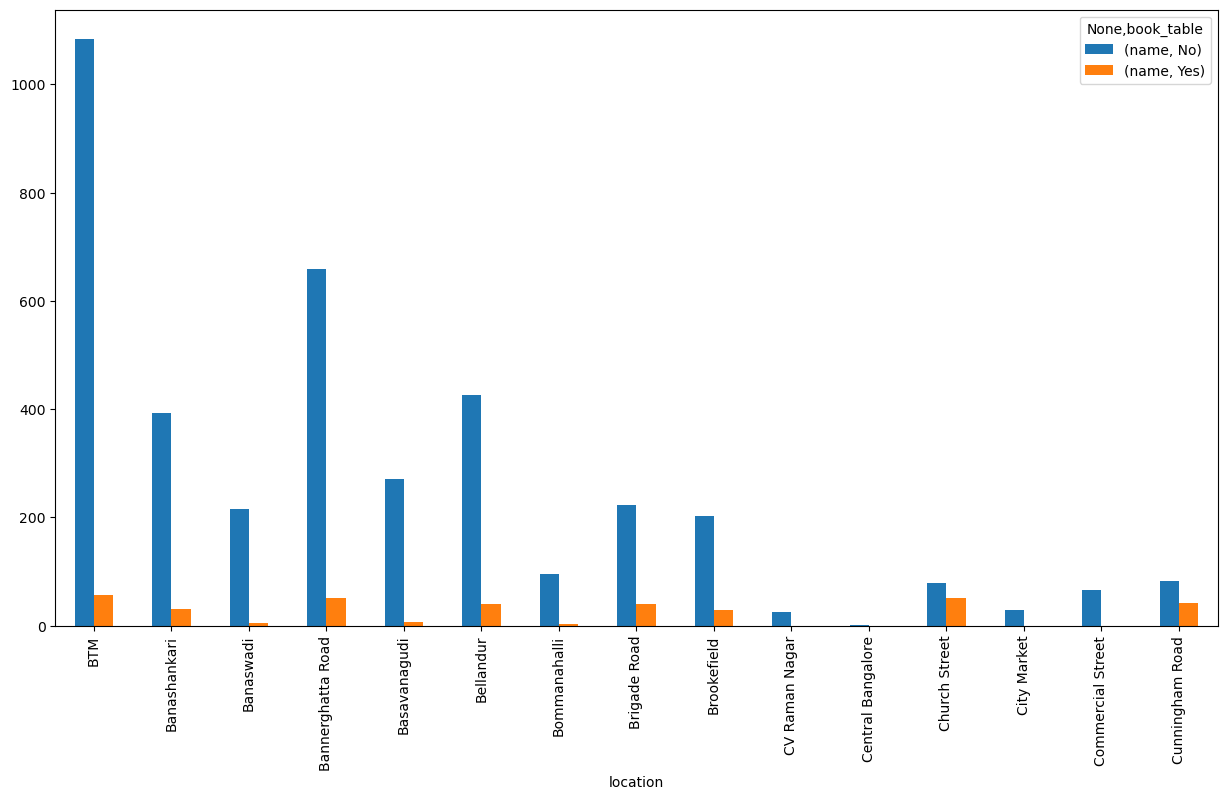

In [262]:
df3.head(15).plot(kind = 'bar', figsize = (15,8))

<Axes: xlabel='Type', ylabel='rate'>

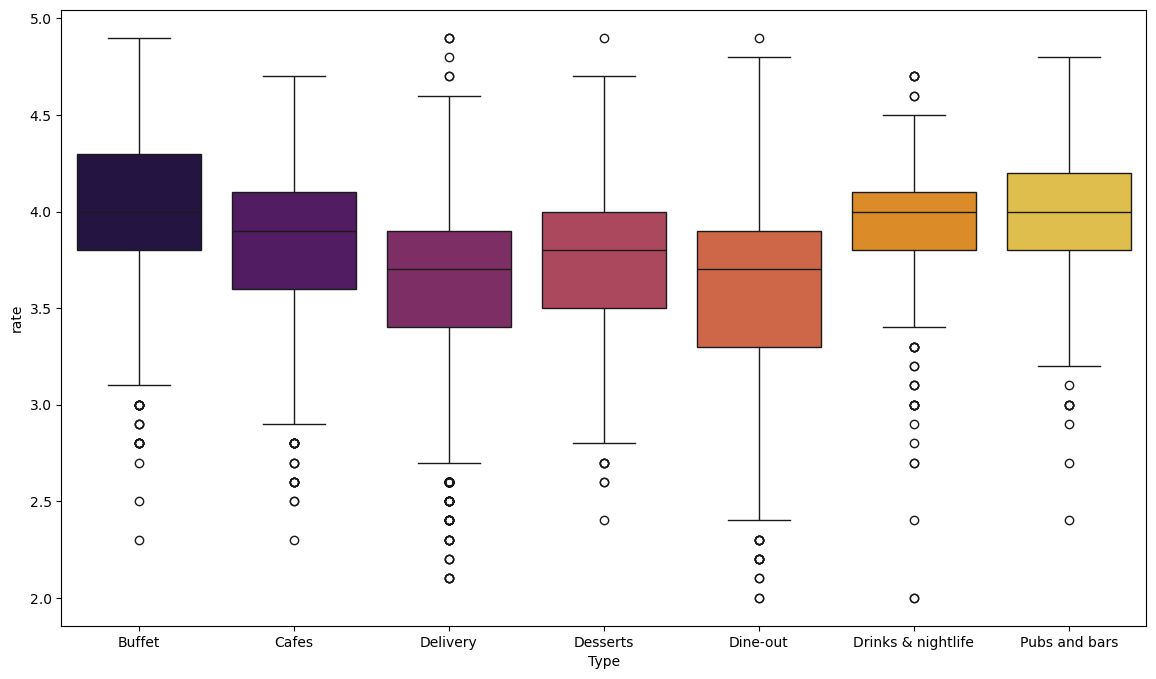

In [263]:
plt.figure(figsize = (14, 8))
sns.boxplot(x = 'Type', y = 'rate', data = data1, palette = 'inferno',orient='v')

In [264]:
df4 = data1.groupby(['location','Type'])['name'].count()
df4.to_csv('location_Type.csv')
df4 = pd.read_csv('location_Type.csv')
df4 = pd.pivot_table(df4, values=None, index=['location'], columns=['Type'], fill_value=0, aggfunc=np.sum)
df4

name                                   \
Type                          Buffet Cafes Delivery Desserts Dine-out   
location                                                                
BTM                                6    27      701       29      364   
Banashankari                       5    24      189       38      161   
Banaswadi                          0    10      112       13       80   
Bannerghatta Road                  6    20      359       54      262   
Basavanagudi                       3     8      142       36       86   
Bellandur                         14    16      210       35      177   
Bommanahalli                       1     0       53        3       39   
Brigade Road                       7    10      106       22      101   
Brookefield                        2     9      100       21       99   
CV Raman Nagar                     0     1       15        2        7   
Central Bangalore                  0     0        1        0        0   
Church Street                      3     7       48        6       49   
City Market                        0     1       10        1       17   
Commercial Street                  0     2       21       15       27   
Cunningham Road                    7     8       44        8       50   
Domlur                             5     5       70        9       39   
East Bangalore                     0     0        7        1        1   
Ejipura                            0     0       39        2        0   
Electronic City                   18    14      331       45      332   
Frazer Town                        1     8      124       30       89   
HBR Layout                         0     2       22        3       18   
HSR                                9    28      608       77      303   
Hennur                             0     2       42        4       16   
Hosur Road                         0     0       15        0        6   
ITPL Main Road, Whitefield         0     1       21        2        4   
Indiranagar                       13    46      353       73      250   
Infantry Road                      5     2        5        1       16   
JP Nagar                          21    33      463       69      273   
Jayanagar                         15    38      350       81      190   
Jeevan Bhima Nagar                 0     2       57        4       48   
Kaggadasapura                      0     0        1        0        0   
Kalyan Nagar                       8    15      138       31      124   
Kammanahalli                       2    10      120       11       86   
Kanakapura Road                    0     0       13        0        5   
Kengeri                            0     1        1        1        1   
Koramangala                        0     0        8        0        0   
Koramangala 1st Block              2     4      128       10       29   
Koramangala 2nd Block              2     4        9        1        5   
Koramangala 3rd Block              6     5       16        3        6   
Koramangala 4th Block              4    14       87        4        9   
Koramangala 5th Block             14    36      248       35      119   
Koramangala 6th Block              5    10      120       15        7   
Koramangala 7th Block              6    15      112       21       63   
Koramangala 8th Block              0     3       35        4        0   
Kumaraswamy Layout                 0     0       79        2       23   
Langford Town                      0     0        1        0        2   
Lavelle Road                       7     7       27       12       42   
MG Road                           12    20       51       15       80   
Majestic                           0     0        3        2        0   
Marathahalli                       6     8      292       18      119   
Mysore Road                        1     0        6        0        8   
Nagawara                           0     0       83        2        8   
North Bangalore  

<Axes: xlabel='location'>

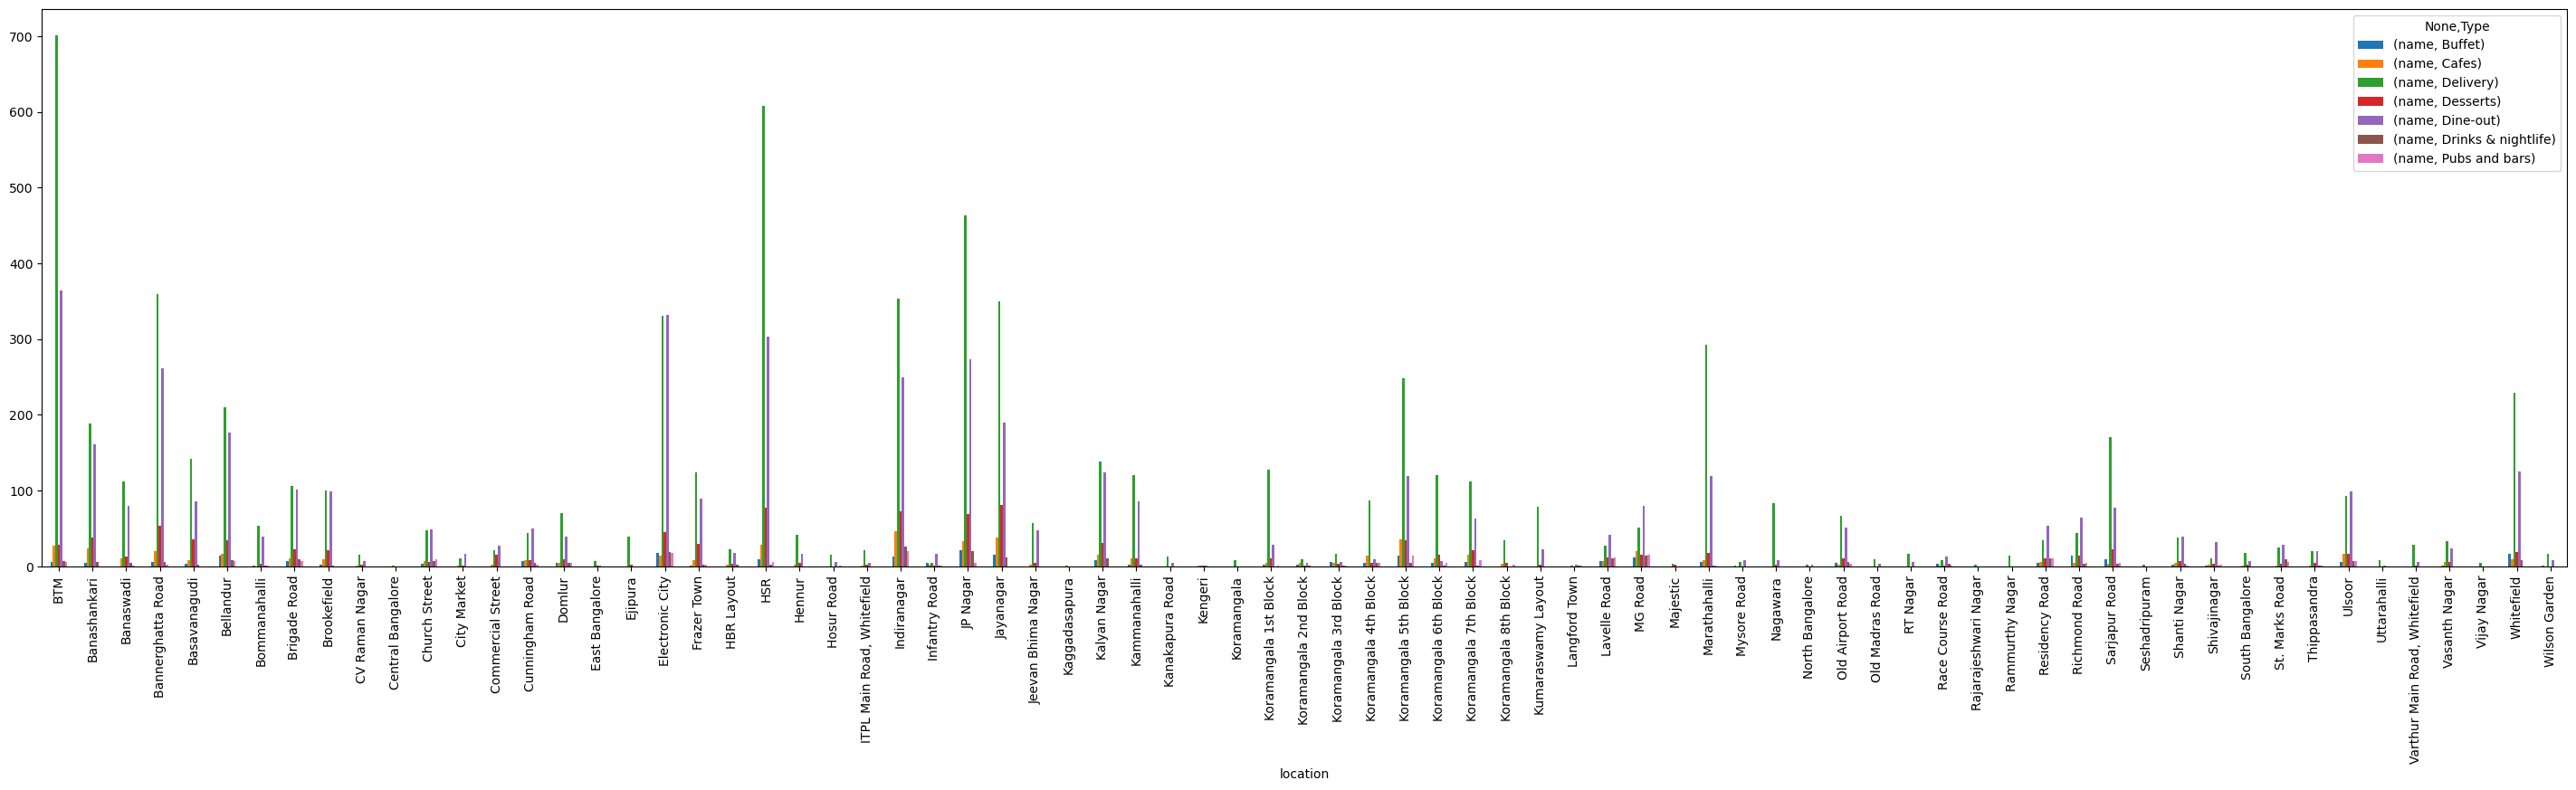

In [265]:
df4.plot(kind = 'bar', figsize = (36,8))


In [266]:
df4 = df[['location', 'votes']]
df4.drop_duplicates()


,location,votes
0,Banashankari,775
1,Banashankari,787
2,Banashankari,918
3,Banashankari,88
4,Basavanagudi,166
...,...,...
55953,('Rated 5.0',it stands right where it should be. The LIIT ...
55955,main course,"""""RATED\n This is a spacious microbrewery wi..."
55957,NaN,('Rated 4.0'
55959,Chicken Dumplings in Soup,Pulled Chicken Bun


In [267]:
# Step 1: Take only location and votes
df4 = df[['location', 'votes']].drop_duplicates()

# Step 2: Convert votes to numeric (force errors to NaN)
df4['votes'] = pd.to_numeric(df4['votes'], errors='coerce')

# Step 3: Group and sort
# df5 = df4.groupby('location')['votes'].sum().reset_index()
# df5 = df5.sort_values('votes', ascending=False)

# # Step 4: Display top results
# df5.shape

In [268]:
df5 = df4.groupby('location')['votes'].sum().sort_values(ascending=False).head(20)

<Axes: xlabel='location'>

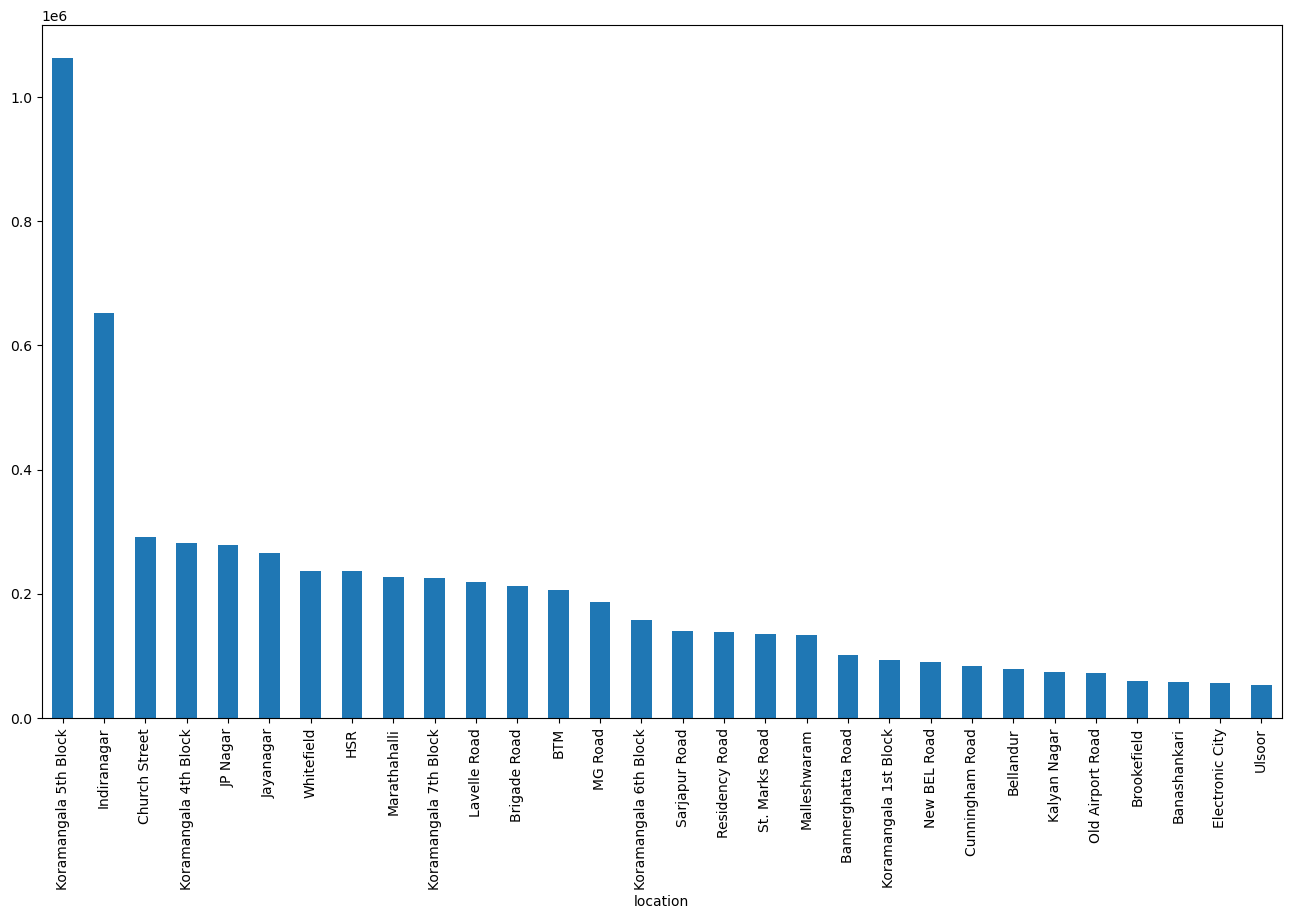

In [269]:
plt.figure(figsize=(16,9))
df4.groupby('location')['votes'].sum().sort_values(ascending=False).head(30).plot.bar()

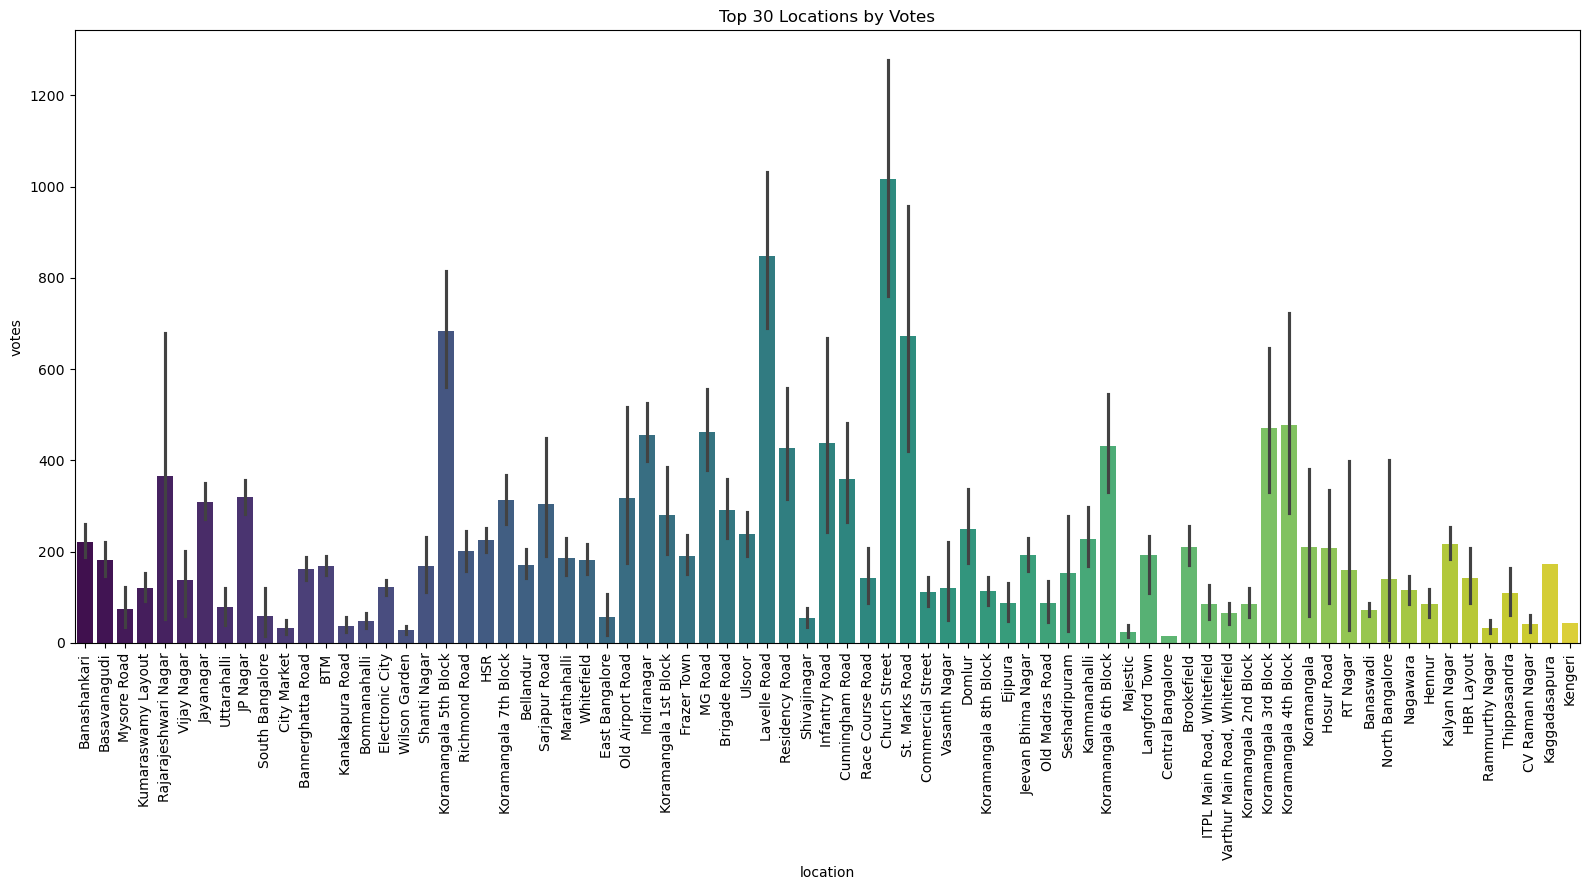

In [271]:
plt.figure(figsize=(16, 9))
sns.barplot(data=data1, x='location', y='votes', palette='viridis')  # try 'magma', 'coolwarm', 'cubehelix' etc.
plt.xticks(rotation=90)
plt.title('Top 30 Locations by Votes')
plt.tight_layout()
plt.show()

In [272]:
data1['rate'] = data1['rate'].astype(str).str.replace('/5', '').replace('NEW', '0').replace('-', '0')
data1['rate'] = pd.to_numeric(data1['rate'], errors='coerce')

# Drop rows with missing 'rate' or 'rest_type'
data_clean = data1.dropna(subset=['rate', 'rest_type'])

# Group by 'rest_type' and find the maximum rate
max_rate_per_type = data_clean.groupby('rest_type')['rate'].max().sort_values(ascending=False)

# Display the result
print(max_rate_per_type)



rest_type
Casual Dining    4.9
others           4.9
Quick Bites      4.8
Cafe             4.6
Name: rate, dtype: float64


In [273]:
data1['rate'] = data1['rate'].astype(str).str.replace('/5', '').replace('NEW', '0').replace('-', '0')
data1['rate'] = pd.to_numeric(data1['rate'], errors='coerce')

# Step 2: Drop rows with missing values in 'rate' or 'rest_type'
data_clean = data1.dropna(subset=['rate', 'rest_type'])

# Step 3: For each 'rest_type', find the restaurant with the highest rating
max_rated_restaurants = data_clean.loc[data_clean.groupby('rest_type')['rate'].idxmax()]

# Step 4: Display selected columns for clarity
result = max_rated_restaurants[['name', 'rest_type', 'rate']]
print(result.sort_values(by='rate', ascending=False))

                             name      rest_type  rate
5367                 Punjab Grill  Casual Dining   4.9
3487  Byg Brewski Brewing Company         others   4.9
2456         Brahmin's Coffee Bar    Quick Bites   4.8
138      The Blue Wagon - Kitchen           Cafe   4.6


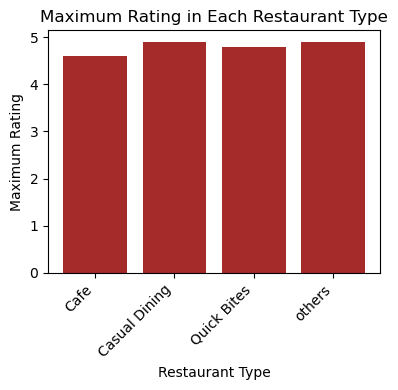

In [274]:
plt.figure(figsize=(4,4))
plt.bar(result['rest_type'], result['rate'], color='brown')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Restaurant Type')
plt.ylabel('Maximum Rating')
plt.title('Maximum Rating in Each Restaurant Type')
plt.tight_layout()
plt.show()

In [275]:
data1['rate'] = data1['rate'].astype(str)

# Now safely use string functions
data1['rate'] = data1['rate'].replace(['NEW', '-'], None)
data1['rate'] = data1['rate'].str.replace('/5', '', regex=False)

# Convert cleaned string to numeric
data1['rate'] = pd.to_numeric(data1['rate'], errors='coerce')

In [276]:
data1_cleaned = data1.dropna(subset=['rate'])

# Get highest rated restaurant
highest_rated = data1_cleaned.loc[data1_cleaned['rate'].idxmax()]
print(highest_rated[['name']])

name    Byg Brewski Brewing Company
Name: 3487, dtype: object


In [277]:
data1 = data1.dropna(subset=['votes', 'rest_type'])

# Convert votes to numeric if it's not already
data1['votes'] = pd.to_numeric(data1['votes'], errors='coerce')

# Find the restaurant with the highest votes in each rest_type
highest_votes_by_type = data1.loc[data1.groupby('rest_type')['votes'].idxmax()]

# Display the relevant columns
print(highest_votes_by_type[['rest_type', 'name', 'votes']])


           rest_type                         name  votes
15277           Cafe    The Hole in the Wall Cafe   7113
12297  Casual Dining            Empire Restaurant   8185
2455     Quick Bites    Mavalli Tiffin Room (MTR)   2896
3487          others  Byg Brewski Brewing Company  16345


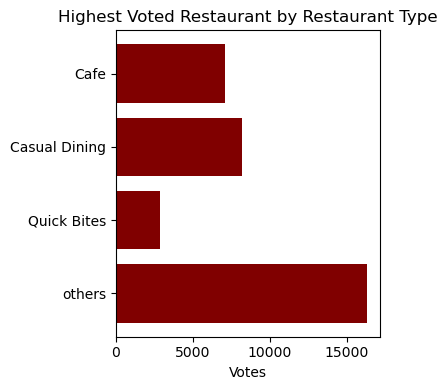

In [278]:
plt.figure(figsize=(4,4))
plt.barh(highest_votes_by_type['rest_type'], highest_votes_by_type['votes'], color='maroon')
plt.xlabel("Votes")
plt.title("Highest Voted Restaurant by Restaurant Type")
plt.gca().invert_yaxis()  # Highest vote at top
plt.tight_layout()
plt.show()

Popular Locations:

Koramangala 5th Block, Indiranagar, and Church Street receive the highest number of customer votes, showing they are major food hubs.

Impact of Online Ordering:

Restaurants offering online ordering generally have slightly higher ratings than those that don’t.

In almost all locations, restaurants with online ordering dominate, confirming that online ordering is highly demanded by customers.

Impact of Table Booking:

Restaurants that offer table booking have noticeably better ratings compared to those without the option.

However, very few restaurants provide table booking, showing it’s a niche feature but valued by customers.

Location-Wise Online Order and Table Booking:

Locations like Koramangala and Indiranagar have a higher number of online-order-enabled restaurants.

Table booking is less frequent across locations, but wherever available, it correlates with higher customer ratings.

Customer Behavior Insights:

Customers prefer restaurants that offer convenience like online ordering.

Premium and highly rated restaurants often offer table booking, reflecting a more luxurious dining experience.

✨ Final Insight:
"Convenience (online orders) drives popularity, while premium services (table booking) drive customer satisfaction and higher ratings. Top dining locations are clear hotspots for both trends."